# P01. Orbits and Insolation

A `System` links worlds gravitationally: a host body (often, but not always, the star) and one or more worlds orbiting it, each with its own orbital elements. This demo places the Earth around the Sun and checks the orbital frequency the system computes. It then calculates the planet's insolation and equilibrium temperature, and the habitable zone across stellar types.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G, au, L_sol, M_sol, R_sol
from TidalPy.Structures import System, StarWorld, build_world

star = build_world("sol")
planet = build_world("earth_simple")

system = System("Star-Planet")
system.add_world(star, is_star=True)
system.add_world(planet, tidal_host=star, semi_major_axis=au, eccentricity=0.0167)

print("worlds:", [world.name for world in system])
print("star:", system.star.name)

worlds: ['Sol', 'Earth-Simple']
star: Sol


A system tracks a world's orbit about its tidal host and its orbit about the star separately, since a moon's host is a planet (notebook S03). Here the star is the planet's tidal host, so one orbit serves both.

## Orbital Frequency

The system computes the orbital (mean-motion) frequency from the two masses and their separation using Kepler's third law. Below, it is checked against the closed-form value and converted to an orbital period.

In [2]:
n = system.calc_orbital_frequency(planet)
n_kepler = np.sqrt(G * (star.mass + planet.mass) / au**3)
period_days = 2.0 * np.pi / n / 86400.0

print(f"orbital frequency (system): {n:.6e} rad/s")
print(f"orbital frequency (Kepler): {n_kepler:.6e} rad/s")
print(f"orbital period: {period_days:.2f} days ({period_days / 365.25:.3f} yr)")

orbital frequency (system): 1.990999e-07 rad/s
orbital frequency (Kepler): 1.990999e-07 rad/s
orbital period: 365.25 days (1.000 yr)


## Insolation and Equilibrium Temperature

The star's luminosity $L$ sets the flux reaching the planet. Averaged over an orbit of semi-major axis $a$ and eccentricity $e$, it is $F = L / (4 \pi a^2 \sqrt{1 - e^2})$, so Earth's eccentricity of 0.0167 raises it by 0.014 percent over a circular orbit at 1 au. The planet converts that flux into an equilibrium temperature through its albedo $A$ and emissivity $\epsilon$, $T_{eq} = [(1 - A) F / (4 \epsilon \sigma)]^{1/4}$, which assumes a fast rotator with a uniform surface temperature. With Earth-Simple's default albedo of 0.3 and emissivity of 1, this gives Earth's equilibrium temperature of about 255 K.

In [3]:
flux = system.calc_insolation_flux(planet)
t_eq_earth = system.calc_equilibrium_temperature(planet)
print(f"insolation flux, e = 0.0167: {flux:.1f} W/m^2")
print(f"insolation flux, circular orbit: {star.calc_insolation_flux(au):.1f} W/m^2")
print(f"albedo: {planet.albedo}, emissivity: {planet.emissivity}")
print(f"equilibrium temperature: {t_eq_earth:.1f} K")

insolation flux, e = 0.0167: 1361.4 W/m^2
insolation flux, circular orbit: 1361.2 W/m^2
albedo: 0.3, emissivity: 1.0
equilibrium temperature: 254.6 K


## Habitable Zone Across Stellar Types

Earth's equilibrium temperature is below freezing. Its surface is warmer, about 288 K, because its atmosphere's greenhouse effect warms it, so a habitable zone is defined on the flux a planet receives rather than on its equilibrium temperature. Kopparapu et al. (2013) used a climate model to find the effective flux $S_{eff}$, in units of the flux at Earth, at which an Earth-like planet loses its water to a runaway greenhouse (the conservative inner edge) and at which a CO$_2$ greenhouse can no longer keep its surface above freezing (the maximum greenhouse, the conservative outer edge). Both limits depend on the star's effective temperature through their fit $S_{eff} = S_{eff,\odot} + a T + b T^2 + c T^3 + d T^4$, with $T = T_{eff} - 5780$ K, valid from 2600 to 7200 K. An edge lies at $d = \sqrt{(L / L_\odot) / S_{eff}}$ au.

The plot shows the planet's equilibrium temperature against orbital distance for four main-sequence stars (with approximate radii and masses), and each star's conservative habitable zone as the thick part of its curve. Earth (the star marker) sits inside the Sun's zone, 0.98 to 1.71 au. The zone moves inward around a cooler, dimmer star, and its flux limits fall, since a planet's atmosphere absorbs more and scatters less of a redder star's light (Kopparapu et al. 2013). With the albedo held at 0.3, the edges therefore sit at lower equilibrium temperatures for cooler stars.

star      L (L_sun)  inner edge (au)  outer edge (au)
M dwarf      0.0085            0.099            0.192
K dwarf      0.1810            0.444            0.810
G (Sun)      1.0000            0.976            1.707
F star       2.8891            1.575            2.717


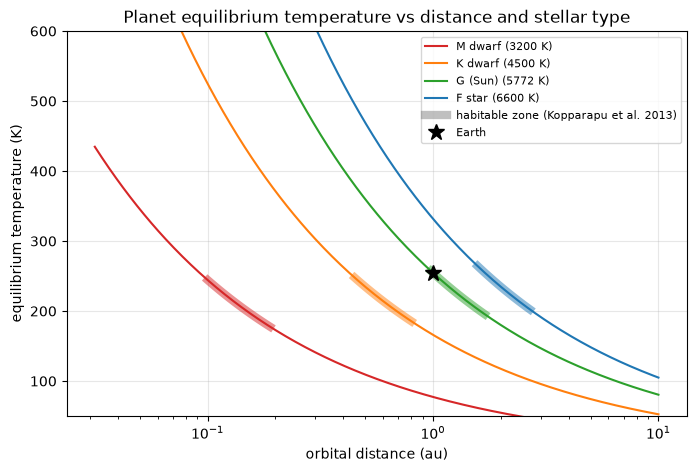

In [4]:
# Kopparapu et al. (2013), Table 3: S_eff at 5780 K, then the coefficients a, b, c, d of the T_eff fit
RUNAWAY_GREENHOUSE = (1.0512, 1.3242e-4, 1.5418e-8, -7.9895e-12, -1.8328e-15)
MAXIMUM_GREENHOUSE = (0.3438, 5.8942e-5, 1.6558e-9, -3.0045e-12, -5.2983e-16)


def habitable_zone_edges(stellar):
    "Conservative habitable-zone edges [m] of a star with an effective temperature of 2600 to 7200 K."
    temperature_offset = stellar.effective_temperature - 5780.0
    edges = []
    for coefficients in (RUNAWAY_GREENHOUSE, MAXIMUM_GREENHOUSE):
        effective_flux = np.polynomial.polynomial.polyval(temperature_offset, coefficients)
        edges.append(np.sqrt(stellar.luminosity / L_sol / effective_flux) * au)
    return edges


# Representative main-sequence stars: name, effective temperature [K], radius, mass, and plot color
stellar_types = [
    ("M dwarf", 3200.0, 0.30 * R_sol, 0.30 * M_sol, "tab:red"),
    ("K dwarf", 4500.0, 0.70 * R_sol, 0.70 * M_sol, "tab:orange"),
    ("G (Sun)", 5772.0, 1.00 * R_sol, 1.00 * M_sol, "tab:green"),
    ("F star", 6600.0, 1.30 * R_sol, 1.30 * M_sol, "tab:blue"),
]

distances = np.logspace(-1.5, 1.0, 400) * au  # 0.03 to 10 au

print(f"{'star':8} {'L (L_sun)':>10} {'inner edge (au)':>16} {'outer edge (au)':>16}")
fig, ax = plt.subplots(figsize=(8, 5))
for label, effective_temperature, radius, mass, color in stellar_types:
    stellar = StarWorld(label, radius, mass)
    stellar.set_effective_temperature(effective_temperature)
    inner_edge, outer_edge = habitable_zone_edges(stellar)
    print(f"{label:8} {stellar.luminosity / L_sol:10.4f} {inner_edge / au:16.3f} {outer_edge / au:16.3f}")

    t_eq = planet.calc_equilibrium_temperature(stellar.calc_insolation_flux(distances))
    in_zone = (distances >= inner_edge) & (distances <= outer_edge)
    ax.plot(distances / au, t_eq, color=color, label=f"{label} ({effective_temperature:.0f} K)")
    ax.plot(distances[in_zone] / au, t_eq[in_zone], color=color, lw=6, alpha=0.5)

ax.plot([], [], color="gray", lw=6, alpha=0.5, label="habitable zone (Kopparapu et al. 2013)")
ax.plot(1.0, t_eq_earth, "k*", ms=12, label="Earth")
ax.set_xscale("log")
ax.set_xlabel("orbital distance (au)")
ax.set_ylabel("equilibrium temperature (K)")
ax.set_ylim(50, 600)
ax.set_title("Planet equilibrium temperature vs distance and stellar type")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()